In [1]:
import pathlib
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence

import cebra
from cebra import CEBRA


import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization,
    LSTM, Bidirectional, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow as tf
import polars as pl
from sklearn.metrics import confusion_matrix

import numpy as np
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# ! pip install cebra
#! pip install sktime

# ! pip install git+https://github.com/gon-uri/detach_rocket --quiet


In [3]:
# https://www.kaggle.com/code/ahnc2171/cmi-nnn

DATA_DIR = pathlib.Path('/Users/ashhadulislam/projects/general_data/CMI/ Detect Behavior with Sensor Data/cmi-detect-behavior-with-sensor-data/')  

train_path      = os.path.join(DATA_DIR, "train.csv")
test_path       = os.path.join(DATA_DIR, "test.csv")          #
train_demo_path = os.path.join(DATA_DIR, "train_demographics.csv")
test_demo_path  = os.path.join(DATA_DIR, "test_demographics.csv")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
train_demo = pd.read_csv(train_demo_path)
test_demo  = pd.read_csv(test_demo_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train demo :", train_demo.shape)
train_df = train_df.merge(train_demo, on="subject", how="left")

TOF_COLS = [c for c in train_df.columns if c.startswith("tof_")]
THM_COLS = [c for c in train_df.columns if c.startswith("thm_")]

print("Num ToF cols:", len(TOF_COLS))
print("Num Thermal cols:", len(THM_COLS))




Train shape: (574945, 341)
Test shape : (107, 336)
Train demo : (81, 8)
Num ToF cols: 320
Num Thermal cols: 5


In [4]:
IMU_BASE_COLS = [
    "acc_x","acc_y","acc_z",
    "rot_w","rot_x","rot_y","rot_z"
]

IMU_FEATURE_NAMES = [
    "acc_x", "acc_y", "acc_z",
    "rot_6d_0", "rot_6d_1", "rot_6d_2",
    "rot_6d_3", "rot_6d_4", "rot_6d_5",
    "angular_vel_x", "angular_vel_y", "angular_vel_z",
    "linear_acc_x", "linear_acc_y", "linear_acc_z",
    "jerk_x", "jerk_y", "jerk_z",
    "acc_mag", "jerk_mag",
]

def normalize_quaternion(quat: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(quat, axis=-1, keepdims=True)
    norm = np.where(norm > 1e-8, norm, 1.0)
    return quat / norm

def quaternion_to_6d_rotation(quat: np.ndarray) -> np.ndarray:
    if quat.ndim == 1:
        quat = quat.reshape(1, -1)

    has_nan = np.any(np.isnan(quat), axis=-1)
    result = np.full((*quat.shape[:-1], 6), np.nan, dtype=np.float32)

    valid_mask = ~has_nan & ~np.all(np.isclose(quat, 0), axis=-1)
    if not np.any(valid_mask):
        return result

    valid_quat = quat[valid_mask]
    try:
        valid_quat_norm = normalize_quaternion(valid_quat)
        rotations = R.from_quat(valid_quat_norm)
        rotation_matrices = rotations.as_matrix()
        result[valid_mask] = rotation_matrices[:, :, :2].reshape(-1, 6)
    except (ValueError, RuntimeError):
        pass
    return result.astype(np.float32)

def remove_gravity_from_acc(
    acc_data: np.ndarray,
    rot_data: np.ndarray,
    gravity_world: np.ndarray = np.array([0, 0, 9.81], dtype=np.float32),
) -> np.ndarray:
    num_samples = acc_data.shape[0]
    linear_accel = np.full_like(acc_data, np.nan, dtype=np.float32)

    for i in range(num_samples):
        acc_i = acc_data[i]
        quat_i = rot_data[i]

        if np.any(np.isnan(acc_i)) or np.any(np.isnan(quat_i)):
            continue
        if np.all(np.isclose(quat_i, 0)):
            linear_accel[i] = acc_i
            continue

        try:
            quat_norm = normalize_quaternion(quat_i.reshape(1, -1))[0]
            rot = R.from_quat(quat_norm)
            gravity_sensor = rot.apply(gravity_world, inverse=True)
            linear_accel[i] = acc_i - gravity_sensor
        except (ValueError, RuntimeError):
            continue

    return linear_accel

def calculate_angular_velocity_from_quat(
    rot_data: np.ndarray,
    time_delta: float = 1/100.0,
) -> np.ndarray:
    num_samples = rot_data.shape[0]
    angular_vel = np.full((num_samples, 3), np.nan, dtype=np.float32)

    for i in range(num_samples - 1):
        q_t = rot_data[i]
        q_tp = rot_data[i + 1]

        if np.any(np.isnan(q_t)) or np.any(np.isnan(q_tp)):
            continue
        if np.all(np.isclose(q_t, 0)) or np.all(np.isclose(q_tp, 0)):
            continue
        try:
            q_t_norm  = normalize_quaternion(q_t.reshape(1, -1))[0]
            q_tp_norm = normalize_quaternion(q_tp.reshape(1, -1))[0]
            rot_t  = R.from_quat(q_t_norm)
            rot_tp = R.from_quat(q_tp_norm)
            delta_rot = rot_t.inv() * rot_tp
            angular_vel[i] = delta_rot.as_rotvec() / time_delta
        except (ValueError, RuntimeError):
            continue

    return angular_vel

def make_imu_features_from_np(data: np.ndarray) -> np.ndarray:
    """
    data: (T, 8) = [acc_x,acc_y,acc_z, rot_x,rot_y,rot_z,rot_w, handedness]
    """
    acc = data[:, :3].copy()
    rot = data[:, 3:7].copy()
    handedness = data[0, 7]

    feat = acc.copy()

    rot_6d = quaternion_to_6d_rotation(rot)
    feat = np.concatenate([feat, rot_6d], axis=1)

    angular_velocity = calculate_angular_velocity_from_quat(rot)
    feat = np.concatenate([feat, angular_velocity], axis=1)

    linear_acc = remove_gravity_from_acc(acc, rot)
    feat = np.concatenate([feat, linear_acc], axis=1)

    feat = np.nan_to_num(feat, nan=0.0).astype(np.float32)

    if handedness == 0:
        feat[:, 0] *= -1.0
        feat[:, 3] *= -1.0
        feat[:, 7] *= -1.0
        feat[:, 9]  *= -1.0
        feat[:, 10] *= -1.0
        feat[:, 11] *= -1.0
        feat[:, 12] *= -1.0
        feat[:, 13] *= -1.0

    lin = feat[:, -3:].astype(np.float32)
    jerk = np.zeros_like(lin, dtype=np.float32)
    if len(lin) > 1:
        jerk[1:] = lin[1:] - lin[:-1]

    acc_mag  = np.linalg.norm(lin, axis=1)
    jerk_mag = np.linalg.norm(jerk, axis=1)

    feat = np.concatenate(
        [
            feat,
            jerk,
            acc_mag[:, None],
            jerk_mag[:, None],
        ],
        axis=1,
    )

    return feat.astype(np.float32)

def preprocess_sequence_multisensor(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.sort_values("sequence_counter").reset_index(drop=True)

    grp[IMU_BASE_COLS] = grp[IMU_BASE_COLS].ffill().bfill()

    acc_np = grp[["acc_x","acc_y","acc_z"]].values.astype(np.float32)
    rot_np = grp[["rot_x","rot_y","rot_z","rot_w"]].values.astype(np.float32)
    handed = grp["handedness"].fillna(1).values.astype(np.float32)

    imu_data_np = np.concatenate([acc_np, rot_np, handed.reshape(-1,1)], axis=1)
    imu_feat_np = make_imu_features_from_np(imu_data_np)

    for i, c in enumerate(IMU_FEATURE_NAMES):
        grp[c] = imu_feat_np[:, i]

    if len(TOF_COLS) > 0:
        tof_vals = grp[TOF_COLS].values.astype(np.float32)
        max_val = 254.0
        mask_neg1 = (tof_vals == -1)
        tof_vals[mask_neg1] = max_val
        tof_vals = tof_vals / max_val
        tof_vals = np.nan_to_num(tof_vals, nan=0.0)
        grp[TOF_COLS] = tof_vals

    if len(THM_COLS) > 0:
        grp[THM_COLS] = grp[THM_COLS].ffill().bfill()
        grp[THM_COLS] = grp[THM_COLS].fillna(method="ffill").fillna(method="bfill").fillna(0)

    eps = 1e-6

    imu_cols = IMU_FEATURE_NAMES
    for c in imu_cols:
        mu  = grp[c].mean()
        std = grp[c].std()
        if std < eps:
            std = eps
        grp[c] = (grp[c] - mu) / std

    if len(TOF_COLS) > 0:
        for c in TOF_COLS:
            mu  = grp[c].mean()
            std = grp[c].std()
            if std < eps:
                std = eps
            grp[c] = (grp[c] - mu) / std

    if len(THM_COLS) > 0:
        for c in THM_COLS:
            mu  = grp[c].mean()
            std = grp[c].std()
            if std < eps:
                std = eps
            grp[c] = (grp[c] - mu) / std

    grp[imu_cols] = grp[imu_cols].ffill().bfill().fillna(0)
    if len(TOF_COLS) > 0:
        grp[TOF_COLS] = grp[TOF_COLS].ffill().bfill().fillna(0)
    if len(THM_COLS) > 0:
        grp[THM_COLS] = grp[THM_COLS].ffill().bfill().fillna(0)

    return grp


In [5]:
## below code takes quite a while so we have saved the output dataframe

'''
train_df = train_df.groupby("sequence_id", group_keys=False).apply(preprocess_sequence_multisensor)
print("Train after preprocess:", train_df.shape)
'''

train_df=pd.read_csv('data/extractedPhysicsFeatures_train.csv')

In [6]:
df=train_df

In [7]:
gestures = sorted(df["gesture"].unique())
gesture2idx = {g: i for i, g in enumerate(gestures)}
idx2gesture = {i: g for g, i in gesture2idx.items()}
num_classes = len(gestures)
print("Num gesture classes:", num_classes)

df["y_multi"] = df["gesture"].map(gesture2idx).astype(int)



Num gesture classes: 18


In [8]:
df["y_multi"].unique()

array([ 1,  6, 17,  5, 10,  9,  4,  3,  7,  0, 15, 16, 14, 12, 11, 13,  2,
        8])

In [9]:
drop_thermal_and_tof = True

excluded_cols = {
    "gesture", "sequence_type", "behavior", "orientation",  # train-only targets
    "row_id", "subject", "phase",                            # meta
    "sequence_id", "sequence_counter"                         # ids
}

excluded_cols.update(IMU_BASE_COLS) # also remove Raw IMU columns

thermal_tof_cols = [c for c in df.columns if c.startswith(("thm_", "tof_"))]

if drop_thermal_and_tof:
    excluded_cols.update(thermal_tof_cols)
    print(f"Ignoring {len(thermal_tof_cols)} thermopile/TOF channels → set drop_thermal_and_tof=False to use them.")

# --- NEW: demographic numeric columns --------------------------------
demographic_cols = [
    "adult_child", "age", "sex", "handedness",
    "height_cm", "shoulder_to_wrist_cm", "elbow_to_wrist_cm",
]

# Combine sensor + demographic feature list
feature_cols = [c for c in df.columns if c not in excluded_cols]
print(f"Using {len(feature_cols)} feature columns for training, including demographics:")
print(sorted(feature_cols)[:15], "…")

# Check missing values
nan_total = df[feature_cols].isna().sum().sum()
print(f"Total NaNs inside feature matrix: {nan_total:,}")

Ignoring 325 thermopile/TOF channels → set drop_thermal_and_tof=False to use them.
Using 25 feature columns for training, including demographics:
['acc_mag', 'adult_child', 'age', 'angular_vel_x', 'angular_vel_y', 'angular_vel_z', 'elbow_to_wrist_cm', 'handedness', 'height_cm', 'jerk_mag', 'jerk_x', 'jerk_y', 'jerk_z', 'linear_acc_x', 'linear_acc_y'] …
Total NaNs inside feature matrix: 0


In [10]:


# ------------------------------------------------------------------
# 4.  SEQUENCE BUILDING HELPERS
# ------------------------------------------------------------------

def preprocess_sequence(df_seq: pd.DataFrame, feature_columns: list[str]) -> np.ndarray:
    """Fill→scale a *single* sequence dataframe and return float32 numpy."""
    data = df_seq[feature_columns].copy()
    data = data.ffill().bfill().fillna(0.0)
    scaled = StandardScaler().fit_transform(data)   # per-sequence scaler (unchanged)
    return scaled.astype("float32")

print("Constructing padded tensor dataset …")
seq_groups = df.groupby("sequence_id")

X, seq_lengths = [], []
for i, (_, seq) in enumerate(seq_groups):
    if i and i % 500 == 0:
        print(f"  processed {i} sequences …")
    arr = preprocess_sequence(seq, feature_cols)
    X.append(arr)
    seq_lengths.append(arr.shape[0])

pad_len = int(np.percentile(seq_lengths, 90))
print(f"90th-percentile length = {pad_len} → fixed pad length chosen")
#np.save("sequence_maxlen.npy", pad_len)


Constructing padded tensor dataset …
  processed 500 sequences …
  processed 1000 sequences …
  processed 1500 sequences …
  processed 2000 sequences …
  processed 2500 sequences …
  processed 3000 sequences …
  processed 3500 sequences …
  processed 4000 sequences …
  processed 4500 sequences …
  processed 5000 sequences …
  processed 5500 sequences …
  processed 6000 sequences …
  processed 6500 sequences …
  processed 7000 sequences …
  processed 7500 sequences …
  processed 8000 sequences …
90th-percentile length = 103 → fixed pad length chosen


In [11]:
X = pad_sequences(X, maxlen=pad_len, dtype="float32", padding="post", truncating="post")

y_multi = seq_groups["y_multi"].first().values
num_classes = len(np.unique(y_multi))
#y = to_categorical(y, num_classes=num_classes)

# ------------------------------------------------------------------
# 5.  TRAIN/VAL SPLIT & MODEL
# ------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y_multi, test_size=0.20, random_state=42, stratify=y_multi
)
print(X.shape,y_multi.shape,X_train.shape,y_train.shape,X_val.shape,y_val.shape)
print(np.unique(y_train),np.unique(y_val))

#y_train_labels = np.argmax(y_train, axis=1)
#y_val_labels = np.argmax(y_val, axis=1)

(8151, 103, 25) (8151,) (6520, 103, 25) (6520,) (1631, 103, 25) (1631,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [12]:
'''
Not including TOF
(8151, 103, 24) (8151, 18) (6520, 103, 24) (6520, 18) (1631, 103, 24) (1631, 18)


When including TOF etc
(8151, 103, 349) (8151, 18) (6520, 103, 349) (6520, 18) (1631, 103, 349) (1631, 18)


'''

'\nNot including TOF\n(8151, 103, 24) (8151, 18) (6520, 103, 24) (6520, 18) (1631, 103, 24) (1631, 18)\n\n\nWhen including TOF etc\n(8151, 103, 349) (8151, 18) (6520, 103, 349) (6520, 18) (1631, 103, 349) (1631, 18)\n\n\n'

In [13]:
### Re shape data for Cebra model

In [14]:
# Flatten trials into one long time series
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_val_flat   = X_val.reshape(-1, X_val.shape[-1])

print(X_train_flat.shape)
print(X_val_flat.shape)

(671560, 25)
(167993, 25)


In [15]:
print(X_train_flat.shape,X_val_flat.shape)

(671560, 25) (167993, 25)


In [16]:
cebra_model = CEBRA(
    model_architecture="offset10-model",
    conditional="time",      # 🔑 UNSUPERVISED
    time_offsets=10,         # ~10% of 103
    output_dimension=8,
    batch_size=512,
    max_iterations=10000,
    device="cuda_if_available",
    verbose=True,
)

In [17]:
cebra_model.fit(X_train_flat)

pos: -0.7647 neg:  6.3806 total:  5.6158 temperature:  1.0000: 100%|██████████| 10000/10000 [01:36<00:00, 103.72it/s]


CEBRA(batch_size=512, conditional='time', model_architecture='offset10-model',
      time_offsets=10, verbose=True)

In [18]:
train_embedding_flat = cebra_model.transform(X_train_flat)
val_embedding_flat   = cebra_model.transform(X_val_flat)

print(train_embedding_flat.shape)
print(val_embedding_flat.shape)

(671560, 8)
(167993, 8)


In [19]:
train_embedding = train_embedding_flat.reshape(
    X_train.shape[0],   # 6520 trials
    X_train.shape[1],   # 103 time steps
    -1                  # latent dim (8)
)

val_embedding = val_embedding_flat.reshape(
    X_val.shape[0],
    X_val.shape[1],
    -1
)

print(train_embedding.shape)
print(val_embedding.shape)

(6520, 103, 8)
(1631, 103, 8)


### Visualize a trial trajectory

Top-variance dims: [2 0 6] variances: [0.06551449 0.05583905 0.04997598]


<Axes3D: title={'center': 'Embedding'}>

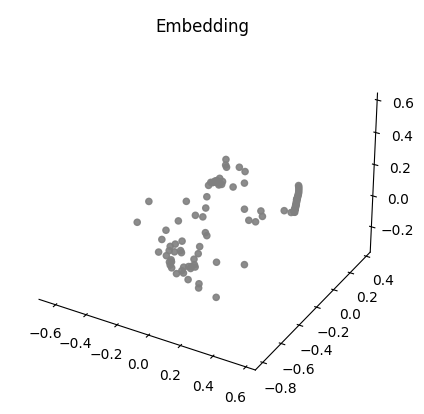

In [20]:
import numpy as np
import cebra

trial = train_embedding[0]  # (103, 8)

var = trial.var(axis=0)
top3 = np.argsort(var)[-3:][::-1]  # indices of top-variance dims

print("Top-variance dims:", top3, "variances:", var[top3])

cebra.plot_embedding(
    trial,
    idx_order=top3,
    markersize=20,
    alpha=0.9
)

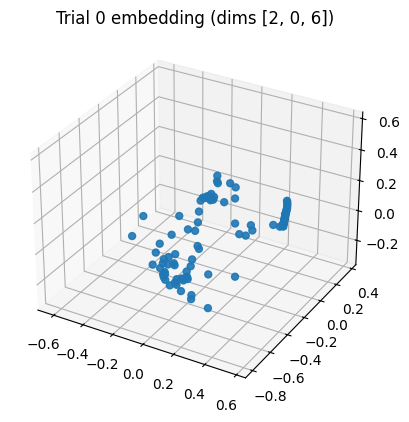

In [21]:
import matplotlib.pyplot as plt

trial = train_embedding[0]
var = trial.var(axis=0)
top3 = np.argsort(var)[-3:][::-1]

x, y, z = trial[:, top3[0]], trial[:, top3[1]], trial[:, top3[2]]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, s=25, alpha=0.9)
ax.set_title(f"Trial 0 embedding (dims {top3.tolist()})")
plt.show()

Using latent dims: [4 6 5]


/var/folders/hl/hqtbxwl95mj2hclnn1hfsc3m0000gn/T/ipykernel_21942/226244467.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_labels))


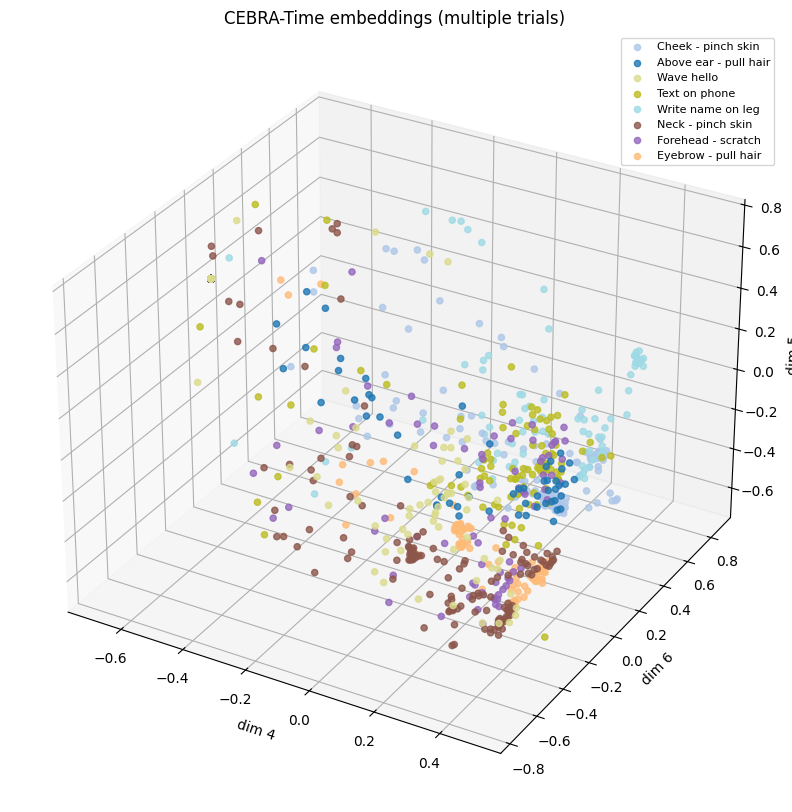

In [22]:
import numpy as np

# use all training embeddings to pick stable dimensions
flat = train_embedding.reshape(-1, train_embedding.shape[-1])
var = flat.var(axis=0)
top3 = np.argsort(var)[-3:][::-1]

print("Using latent dims:", top3)

# choose some trial indices
trial_indices = np.random.choice(train_embedding.shape[0], 10, replace=False)



import matplotlib.pyplot as plt
from matplotlib import cm

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

# colormap for labels
labels = y_train  # trial-level labels
unique_labels = np.unique(labels)
cmap = cm.get_cmap("tab20", len(unique_labels))

for i in trial_indices:
    trial = train_embedding[i]          # (103, 8)
    label = labels[i]

    x = trial[:, top3[0]]
    y = trial[:, top3[1]]
    z = trial[:, top3[2]]

    ax.scatter(
        x, y, z,
        s=20,
        alpha=0.8,
        color=cmap(label),
        label=idx2gesture[label]
    )

# clean legend (avoid duplicates)
handles, legend_labels = ax.get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8)

ax.set_title("CEBRA-Time embeddings (multiple trials)")
ax.set_xlabel(f"dim {top3[0]}")
ax.set_ylabel(f"dim {top3[1]}")
ax.set_zlabel(f"dim {top3[2]}")

plt.show()

### Lets plot trial means

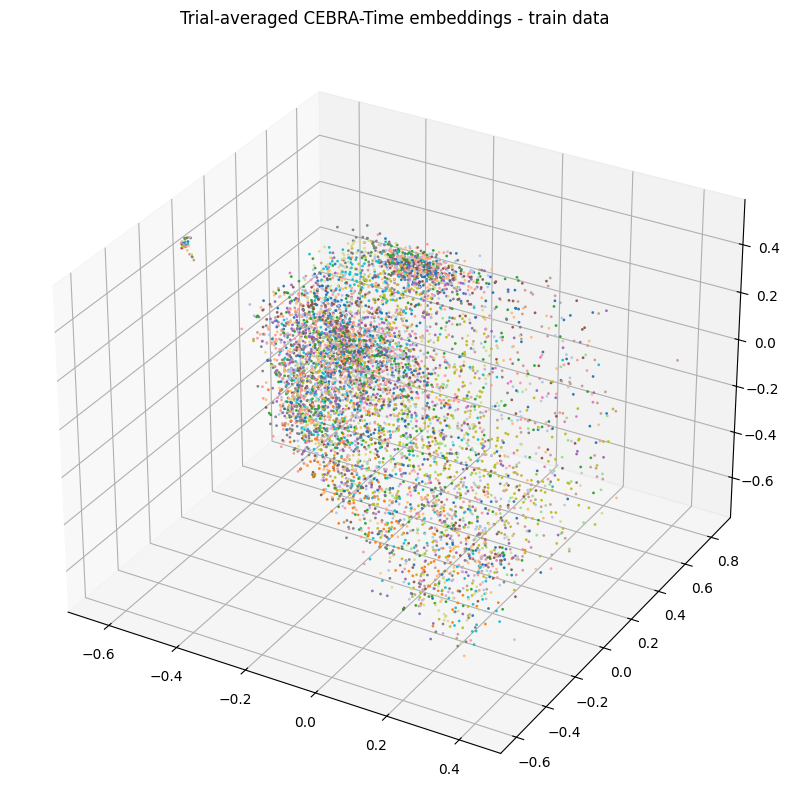

In [23]:
trial_means = train_embedding.mean(axis=1)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    trial_means[:, top3[0]],
    trial_means[:, top3[1]],
    trial_means[:, top3[2]],
    c=y_train,
    cmap="tab20",
    s=1,
    alpha=0.9
)

ax.set_title("Trial-averaged CEBRA-Time embeddings - train data")
plt.show()

In [24]:
idx2gesture

{0: 'Above ear - pull hair',
 1: 'Cheek - pinch skin',
 2: 'Drink from bottle/cup',
 3: 'Eyebrow - pull hair',
 4: 'Eyelash - pull hair',
 5: 'Feel around in tray and pull out an object',
 6: 'Forehead - pull hairline',
 7: 'Forehead - scratch',
 8: 'Glasses on/off',
 9: 'Neck - pinch skin',
 10: 'Neck - scratch',
 11: 'Pinch knee/leg skin',
 12: 'Pull air toward your face',
 13: 'Scratch knee/leg skin',
 14: 'Text on phone',
 15: 'Wave hello',
 16: 'Write name in air',
 17: 'Write name on leg'}

In [25]:
gesture2idx

TARGET_GESTURES = [
    'Above ear - pull hair',
    'Cheek - pinch skin',
    'Eyebrow - pull hair',
    'Eyelash - pull hair',
    'Forehead - pull hairline',
    'Forehead - scratch',
    'Neck - pinch skin',
    'Neck - scratch',
]

NON_TARGET_GESTURES = [
    'Write name on leg',
    'Wave hello',
    'Glasses on/off',
    'Text on phone',
    'Write name in air',
    'Feel around in tray and pull out an object',
    'Scratch knee/leg skin',
    'Pull air toward your face',
    'Drink from bottle/cup',
    'Pinch knee/leg skin',
]

ALL_GESTURES_SET = set(TARGET_GESTURES + NON_TARGET_GESTURES)


y_bin_train=[]
for v in y_train:
    if idx2gesture[v] in TARGET_GESTURES:
        y_bin_train.append(1)
    else:
        y_bin_train.append(0)

y_bin_val=[]
for v in y_val:
    if idx2gesture[v] in TARGET_GESTURES:
        y_bin_val.append(1)
    else:
        y_bin_val.append(0)



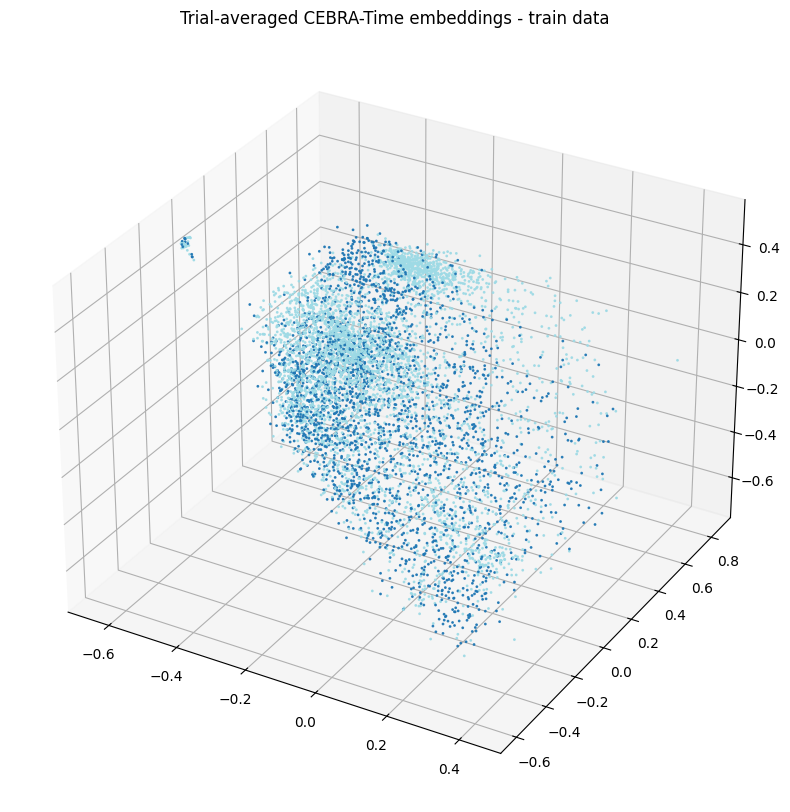

In [26]:


trial_means = train_embedding.mean(axis=1)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    trial_means[:, top3[0]],
    trial_means[:, top3[1]],
    trial_means[:, top3[2]],
    c=y_bin_train,
    cmap="tab20",
    s=1,
    alpha=0.9,
    
)

ax.set_title("Trial-averaged CEBRA-Time embeddings - train data")
plt.show()

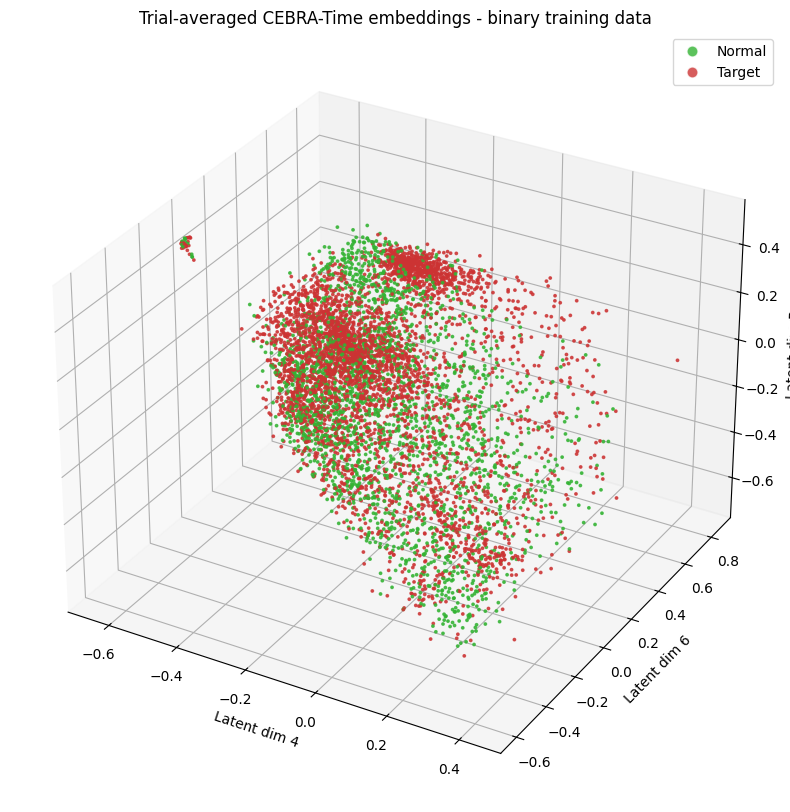

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

trial_means = train_embedding.mean(axis=1)
labels = np.asarray(y_bin_train)  # 🔑 convert list → array

# Explicit color mapping
colors = np.where(
    labels[:, None] == 0,
    np.array([0.2, 0.7, 0.2, 0.8]),  # green RGBA
    np.array([0.8, 0.2, 0.2, 0.8])   # red RGBA
)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    trial_means[:, top3[0]],
    trial_means[:, top3[1]],
    trial_means[:, top3[2]],
    c=colors,
    s=3,
    depthshade=False,
)

ax.set_title("Trial-averaged CEBRA-Time embeddings - binary training data")
ax.set_xlabel(f"Latent dim {top3[0]}")
ax.set_ylabel(f"Latent dim {top3[1]}")
ax.set_zlabel(f"Latent dim {top3[2]}")

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Normal',
           markerfacecolor=(0.2, 0.7, 0.2, 0.8),
           markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label='Target',
           markerfacecolor=(0.8, 0.2, 0.2, 0.8),
           markersize=8),
]

ax.legend(handles=legend_elements)
plt.show()

#### Plot validation data as well

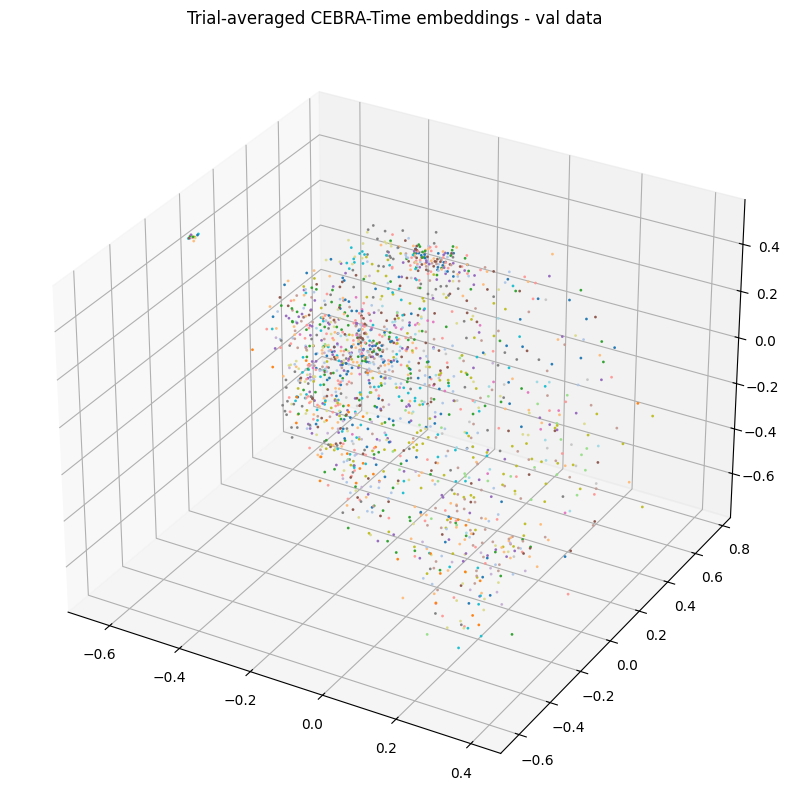

In [28]:
trial_means = val_embedding.mean(axis=1)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    trial_means[:, top3[0]],
    trial_means[:, top3[1]],
    trial_means[:, top3[2]],
    c=y_val,
    cmap="tab20",
    s=1,
    alpha=0.9
)

ax.set_title("Trial-averaged CEBRA-Time embeddings - val data")
plt.show()

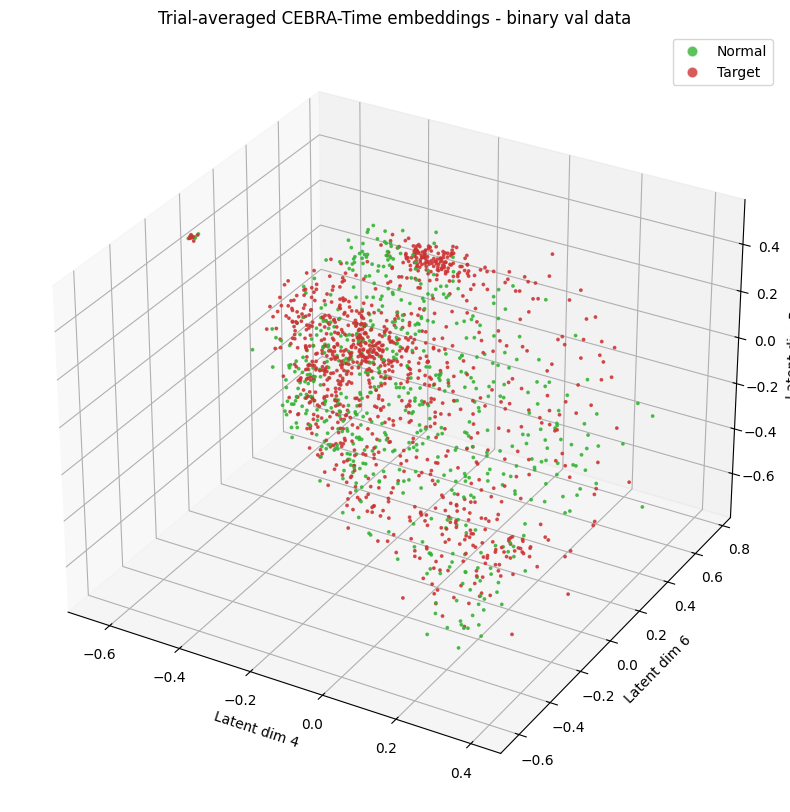

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

trial_means = val_embedding.mean(axis=1)
labels = np.asarray(y_bin_val)  # 🔑 convert list → array

# Explicit color mapping
colors = np.where(
    labels[:, None] == 0,
    np.array([0.2, 0.7, 0.2, 0.8]),  # green RGBA
    np.array([0.8, 0.2, 0.2, 0.8])   # red RGBA
)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    trial_means[:, top3[0]],
    trial_means[:, top3[1]],
    trial_means[:, top3[2]],
    c=colors,
    s=3,
    depthshade=False,
)

ax.set_title("Trial-averaged CEBRA-Time embeddings - binary val data")
ax.set_xlabel(f"Latent dim {top3[0]}")
ax.set_ylabel(f"Latent dim {top3[1]}")
ax.set_zlabel(f"Latent dim {top3[2]}")

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Normal',
           markerfacecolor=(0.2, 0.7, 0.2, 0.8),
           markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label='Target',
           markerfacecolor=(0.8, 0.2, 0.2, 0.8),
           markersize=8),
]

ax.legend(handles=legend_elements)
plt.show()

### Let us use minirocket here

In [30]:
X_train_mr = train_embedding.transpose(0, 2, 1)
X_val_mr   = val_embedding.transpose(0, 2, 1)

print(X_train_mr.shape)

(6520, 8, 103)


In [31]:
minirocket_pipeline = make_pipeline(
    MiniRocketMultivariate(),                  # time-series transform
    StandardScaler(with_mean=False),            # scale features
    RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))  # linear classifier
)
minirocket_pipeline.fit(X_train_mr, y_train)
y_val_pred = minirocket_pipeline.predict(X_val_mr)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [32]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_val, y_val_pred))
print("Macro F1:", f1_score(y_val, y_val_pred, average="macro"))
print("Weighted F1:", f1_score(y_val, y_val_pred, average="weighted"))

              precision    recall  f1-score   support

           0       0.23      0.26      0.24       128
           1       0.16      0.11      0.13       128
           2       0.91      0.62      0.74        32
           3       0.09      0.07      0.08       128
           4       0.25      0.32      0.28       128
           5       0.70      0.50      0.58        32
           6       0.20      0.18      0.19       128
           7       0.26      0.30      0.28       128
           8       0.85      0.69      0.76        32
           9       0.19      0.16      0.17       128
          10       0.20      0.23      0.21       128
          11       0.33      0.16      0.21        32
          12       0.65      0.74      0.69        96
          13       0.36      0.16      0.22        32
          14       0.61      0.79      0.69       128
          15       0.42      0.51      0.46        96
          16       0.41      0.46      0.43        95
          17       0.38    

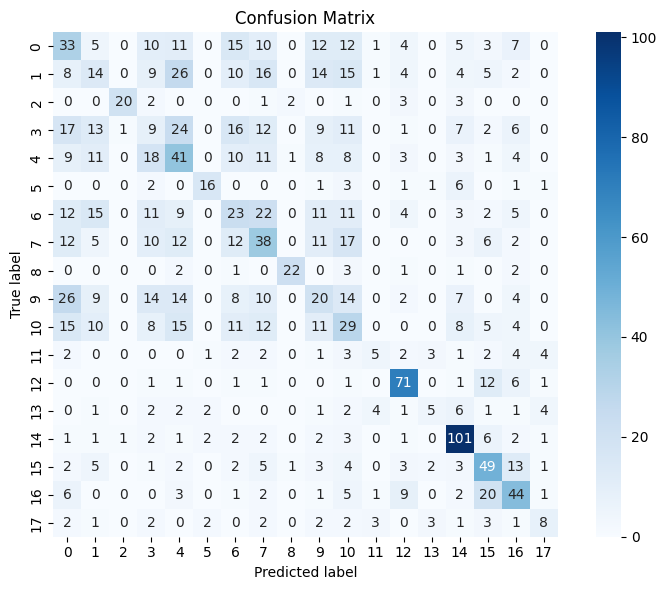

In [33]:


cm = confusion_matrix(y_val, y_val_pred)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt="d",           # integer format
    cmap="Blues",      # color scheme
    cbar=True,
    square=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

### Try Detach


In [34]:
from detach_rocket.detach_classes import DetachEnsemble


In [35]:
num_models = 5
num_kernels = 1000
DetachRocketEnsemble = DetachEnsemble(num_models=num_models, num_kernels=num_kernels)
DetachRocketEnsemble.fit(X_train_mr,y_train)
y_val_pred = DetachRocketEnsemble.predict(X_val_mr)


print(classification_report(y_val, y_val_pred))
print("Macro F1:", f1_score(y_val, y_val_pred, average="macro"))
print("Weighted F1:", f1_score(y_val, y_val_pred, average="weighted"))

TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 4832.93
Train Accuraccy Full ROCKET: 44.68%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 4832.93
Train Accuraccy Detach Model: 39.05%
-------------------------
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 4832.93
Train Accuraccy Full ROCKET: 44.16%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 4832.93
Train Accuraccy Detach Model: 38.60%
-------------------------
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 4832.93
Train Accuraccy Full ROCKET: 45.35%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 4832.93
Train Accuraccy Detach Model: 42.13%
-------------------------
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 4832.93
Train Accuraccy Full ROCKET: 45.23%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 4832.93
Train Accuraccy Detach Model: 44.86

/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

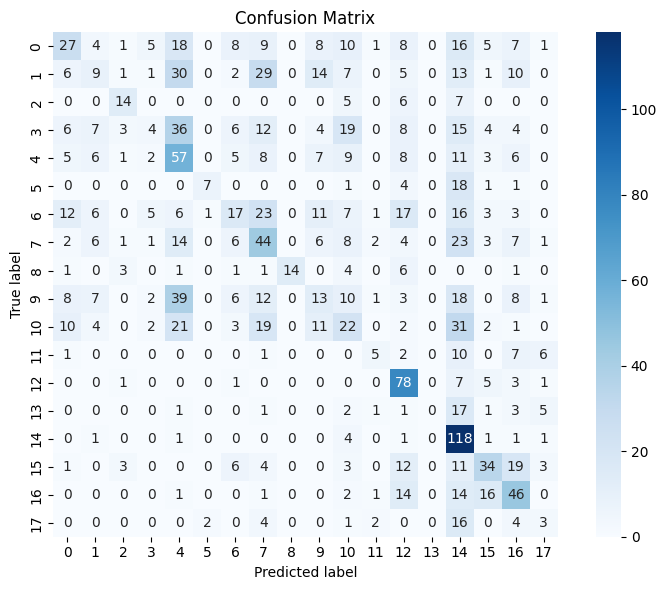

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt="d",           # integer format
    cmap="Blues",      # color scheme
    cbar=True,
    square=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [37]:
Counter(y_train)

Counter({9: 512,
         4: 512,
         10: 512,
         7: 512,
         6: 512,
         14: 512,
         0: 510,
         3: 510,
         1: 509,
         16: 382,
         15: 382,
         12: 381,
         13: 129,
         2: 129,
         5: 129,
         8: 129,
         11: 129,
         17: 129})